In [7]:
import pandas as pd

In [8]:
fund_master=pd.read_csv(r"C:\Users\aksha\OneDrive\Desktop\BLUE STOCK INTERNSHIP\Mutual-Fund-Analysis\data\processed\fund_master_cleaned.csv")
nav_history=pd.read_csv(r"C:\Users\aksha\OneDrive\Desktop\BLUE STOCK INTERNSHIP\Mutual-Fund-Analysis\data\processed\nav_history_cleaned.csv")

In [9]:
# merging the fun_master and nav_history data
nav_df=pd.merge(fund_master,nav_history,on='amfi_code',how='left')

In [10]:
nav_df.dtypes

amfi_code               int64
fund_house                str
scheme_name               str
category                  str
sub_category              str
plan                      str
launch_date               str
benchmark                 str
expense_ratio_pct     float64
exit_load_pct         float64
min_sip_amount          int64
min_lumpsum_amount      int64
fund_manager              str
risk_category             str
sebi_category_code        str
date                      str
nav                   float64
dtype: object

In [11]:
nav_df['date']=pd.to_datetime(nav_df['date'])

In [12]:
nav_df = nav_df.sort_values(['amfi_code', 'date']).reset_index(drop=True)

In [13]:
nav_df.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code,date,nav
0,100016,HDFC Mutual Fund,HDFC Top 100 Fund - Regular Plan - Growth,Equity,Large Cap,Regular,1996-09-11,NIFTY 100 TRI,1.55,1.0,500,1000,Rahul Baijal,Moderate,EC01,2022-01-03,520.4608
1,100016,HDFC Mutual Fund,HDFC Top 100 Fund - Regular Plan - Growth,Equity,Large Cap,Regular,1996-09-11,NIFTY 100 TRI,1.55,1.0,500,1000,Rahul Baijal,Moderate,EC01,2022-01-04,515.0971
2,100016,HDFC Mutual Fund,HDFC Top 100 Fund - Regular Plan - Growth,Equity,Large Cap,Regular,1996-09-11,NIFTY 100 TRI,1.55,1.0,500,1000,Rahul Baijal,Moderate,EC01,2022-01-05,521.7239
3,100016,HDFC Mutual Fund,HDFC Top 100 Fund - Regular Plan - Growth,Equity,Large Cap,Regular,1996-09-11,NIFTY 100 TRI,1.55,1.0,500,1000,Rahul Baijal,Moderate,EC01,2022-01-06,515.7880
4,100016,HDFC Mutual Fund,HDFC Top 100 Fund - Regular Plan - Growth,Equity,Large Cap,Regular,1996-09-11,NIFTY 100 TRI,1.55,1.0,500,1000,Rahul Baijal,Moderate,EC01,2022-01-07,515.1639


In [14]:
# calculating the daily return for the 40 schemes
nav_df['daily_return']=nav_df.groupby('amfi_code')['nav'].pct_change()
nav_df.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code,date,nav,daily_return
0,100016,HDFC Mutual Fund,HDFC Top 100 Fund - Regular Plan - Growth,Equity,Large Cap,Regular,1996-09-11,NIFTY 100 TRI,1.55,1.0,500,1000,Rahul Baijal,Moderate,EC01,2022-01-03,520.4608,NaN
1,100016,HDFC Mutual Fund,HDFC Top 100 Fund - Regular Plan - Growth,Equity,Large Cap,Regular,1996-09-11,NIFTY 100 TRI,1.55,1.0,500,1000,Rahul Baijal,Moderate,EC01,2022-01-04,515.0971,-0.010306
2,100016,HDFC Mutual Fund,HDFC Top 100 Fund - Regular Plan - Growth,Equity,Large Cap,Regular,1996-09-11,NIFTY 100 TRI,1.55,1.0,500,1000,Rahul Baijal,Moderate,EC01,2022-01-05,521.7239,0.012865
3,100016,HDFC Mutual Fund,HDFC Top 100 Fund - Regular Plan - Growth,Equity,Large Cap,Regular,1996-09-11,NIFTY 100 TRI,1.55,1.0,500,1000,Rahul Baijal,Moderate,EC01,2022-01-06,515.7880,-0.011377
4,100016,HDFC Mutual Fund,HDFC Top 100 Fund - Regular Plan - Growth,Equity,Large Cap,Regular,1996-09-11,NIFTY 100 TRI,1.55,1.0,500,1000,Rahul Baijal,Moderate,EC01,2022-01-07,515.1639,-0.001210


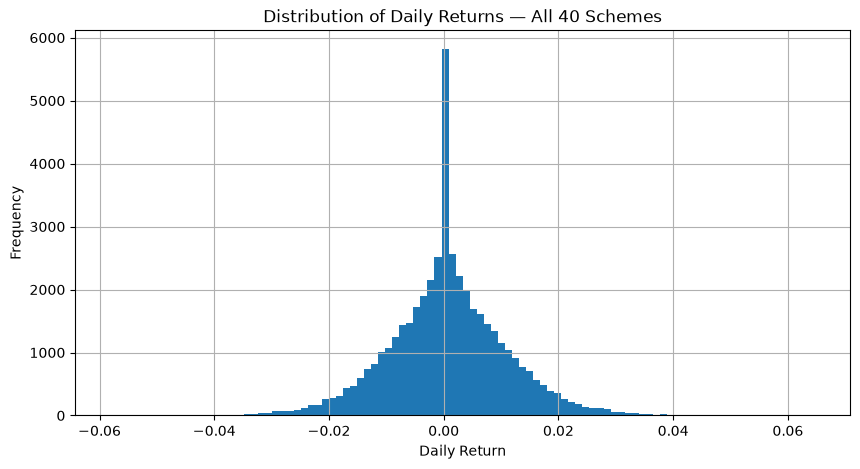

In [15]:
# validating the distribution
import matplotlib.pyplot as plt

nav_df['daily_return'].hist(bins=100, figsize=(10,5))
plt.title('Distribution of Daily Returns — All 40 Schemes')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.show()

In [16]:
sample_code = 100016  # HDFC Top 100, same one we used for Task 1
sample = nav_df[nav_df['amfi_code'] == sample_code].sort_values('date')

In [17]:
end_date = sample['date'].max()
end_nav = sample[sample['date'] == end_date]['nav'].values[0]
    
print("End date:", end_date, "| End NAV:", end_nav)

End date: 2026-05-29 00:00:00 | End NAV: 583.6113


In [18]:
target_date_1yr = end_date - pd.DateOffset(years=1)
print(target_date_1yr)

2025-05-29 00:00:00


In [19]:
rows_after_target = sample[sample['date'] >= target_date_1yr]
rows_after_target = rows_after_target.sort_values('date')
start_1yr_row = rows_after_target.iloc[0]
print(start_1yr_row)

amfi_code                                                100016
fund_house                                     HDFC Mutual Fund
scheme_name           HDFC Top 100 Fund - Regular Plan - Growth
category                                                 Equity
sub_category                                          Large Cap
plan                                                    Regular
launch_date                                          1996-09-11
benchmark                                         NIFTY 100 TRI
expense_ratio_pct                                          1.55
exit_load_pct                                               1.0
min_sip_amount                                              500
min_lumpsum_amount                                         1000
fund_manager                                       Rahul Baijal
risk_category                                          Moderate
sebi_category_code                                         EC01
date                                    

In [20]:
start_1yr_nav = start_1yr_row['nav']
print(start_1yr_nav)

596.8877


In [21]:
cagr_1yr = (end_nav / start_1yr_nav) ** (1/1) - 1
print(f"1yr CAGR: {cagr_1yr:.4f}  ({cagr_1yr*100:.2f}%)")

1yr CAGR: -0.0222  (-2.22%)


In [22]:
target_date_3yr = end_date - pd.DateOffset(years=3)
print(target_date_3yr)

2023-05-29 00:00:00


In [23]:
rows_after_target_3yr = sample[sample['date'] >= target_date_3yr]
rows_after_target_3yr = rows_after_target_3yr.sort_values('date')
start_3yr_row = rows_after_target_3yr.iloc[0]
print(start_3yr_row)

amfi_code                                                100016
fund_house                                     HDFC Mutual Fund
scheme_name           HDFC Top 100 Fund - Regular Plan - Growth
category                                                 Equity
sub_category                                          Large Cap
plan                                                    Regular
launch_date                                          1996-09-11
benchmark                                         NIFTY 100 TRI
expense_ratio_pct                                          1.55
exit_load_pct                                               1.0
min_sip_amount                                              500
min_lumpsum_amount                                         1000
fund_manager                                       Rahul Baijal
risk_category                                          Moderate
sebi_category_code                                         EC01
date                                    

In [25]:
start_3yr_nav = start_3yr_row['nav']
print(start_3yr_nav)

561.5519


In [27]:
cagr_3yr = (end_nav / start_3yr_nav) ** (1/3) - 1
print(f"3yr CAGR: {cagr_3yr:.4f}  ({cagr_3yr*100:.2f}%)")

3yr CAGR: 0.0129  (1.29%)


In [28]:
end_date = nav_df['date'].max()
print(end_date)

end_navs = nav_df[nav_df['date'] == end_date].set_index('amfi_code')['nav']
end_navs.head()

2026-05-29 00:00:00


amfi_code
100016    583.6113
100025     31.8843
100033    342.0072
101206    773.2939
101207     53.9836
Name: nav, dtype: float64

In [29]:
target_date_1yr = end_date - pd.DateOffset(years=1)
target_date_3yr = end_date - pd.DateOffset(years=3)

nav_after_1yr_target = nav_df[nav_df['date'] >= target_date_1yr].sort_values('date')
nav_after_3yr_target = nav_df[nav_df['date'] >= target_date_3yr].sort_values('date')

In [30]:
start_1yr_navs = nav_after_1yr_target.groupby('amfi_code').first()['nav']
start_3yr_navs = nav_after_3yr_target.groupby('amfi_code').first()['nav']

start_1yr_navs.head()

amfi_code
100016    596.8877
100025     30.7452
100033    223.1951
101206    522.7639
101207     71.0180
Name: nav, dtype: float64

In [31]:
# Compute CAGR for all 40 funds at once
cagr_1yr_all = (end_navs / start_1yr_navs) ** (1/1) - 1
cagr_3yr_all = (end_navs / start_3yr_navs) ** (1/3) - 1

cagr_1yr_all.head()

amfi_code
100016   -0.022243
100025    0.037050
100033    0.532324
101206    0.479241
101207   -0.239860
Name: nav, dtype: float64

In [32]:
# Build the final comparison table
cagr_table = pd.DataFrame({
    'cagr_1yr': cagr_1yr_all,
    'cagr_3yr': cagr_3yr_all,
    'cagr_5yr': pd.NA  # not computable — data only spans 4.4 years
})

cagr_table = cagr_table.reset_index()  # turns amfi_code back into a normal column
cagr_table

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,-0.022243,0.012926,<NA>
1,100025,0.037050,0.039164,<NA>
2,100033,0.532324,0.324425,<NA>
3,101206,0.479241,0.289677,<NA>
4,101207,-0.239860,-0.041524,<NA>
5,101208,0.072366,0.063158,<NA>
6,102885,0.202077,0.196673,<NA>
7,102886,-0.167975,-0.007674,<NA>
8,102887,0.135831,0.255562,<NA>
9,118632,0.339810,0.226524,<NA>


In [40]:
cagr_table.columns

Index(['amfi_code', 'cagr_1yr', 'cagr_3yr', 'cagr_5yr', 'scheme_name_x',
       'category_x', 'scheme_name_y', 'category_y', 'scheme_name', 'category'],
      dtype='str')

#### sharp ratio

In [41]:
# Convert annual risk-free rate to a daily rate
annual_rf = 0.065
daily_rf = (1 + annual_rf) ** (1/252) - 1
print(daily_rf)

0.00024993122427763304


In [42]:
mean_daily_return = sample['daily_return'].mean()
std_daily_return = sample['daily_return'].std()

print("Mean daily return:", mean_daily_return)
print("Std daily return:", std_daily_return)

Mean daily return: 0.00014159930699210853
Std daily return: 0.009164463506291045


In [43]:
sharpe_sample = (mean_daily_return - daily_rf) / std_daily_return * (252 ** 0.5)
print(f"Sharpe Ratio: {sharpe_sample:.4f}")

Sharpe Ratio: -0.1877


In [44]:
# Sharpe Ratio to all 40 funds
mean_returns_all = nav_df.groupby('amfi_code')['daily_return'].mean()
std_returns_all = nav_df.groupby('amfi_code')['daily_return'].std()

mean_returns_all.head()

amfi_code
100016    0.000142
100025    0.000170
100033    0.001080
101206    0.000852
101207    0.000424
Name: daily_return, dtype: float64

In [45]:
# Compute Sharpe Ratio for all 40 funds
sharpe_all = (mean_returns_all - daily_rf) / std_returns_all * (252 ** 0.5)
sharpe_all.head()

amfi_code
100016   -0.187650
100025   -0.515438
100033    1.104352
101206    1.041061
101207    0.170481
Name: daily_return, dtype: float64

In [46]:
# Rank all 40 funds by Sharpe Ratio

sharpe_table = pd.DataFrame({'sharpe_ratio': sharpe_all})
sharpe_table = sharpe_table.reset_index()

sharpe_table = sharpe_table.merge(
    fund_master[['amfi_code', 'scheme_name', 'category']],
    on='amfi_code', how='left'
)

sharpe_table['sharpe_rank'] = sharpe_table['sharpe_ratio'].rank(ascending=False)

sharpe_table = sharpe_table.sort_values('sharpe_rank')
sharpe_table[['amfi_code', 'scheme_name', 'category', 'sharpe_ratio', 'sharpe_rank']]

,amfi_code,scheme_name,category,sharpe_ratio,sharpe_rank
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Equity,1.462504,1.0
30,120843,Kotak Flexicap Fund - Regular - Growth,Equity,1.319442,2.0
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,1.246344,3.0
19,119551,SBI Bluechip Fund - Regular Plan - Growth,Equity,1.222947,4.0
25,120505,ICICI Pru Midcap Fund - Regular - Growth,Equity,1.190559,5.0
38,149323,DSP Midcap Fund - Regular - Growth,Equity,1.143490,6.0
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,1.104352,7.0
9,118632,Nippon India Large Cap Fund - Regular - Growth,Equity,1.095918,8.0
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Equity,1.041061,9.0
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,Equity,1.040569,10.0


#### Sort ratio

In [47]:
# Isolate only the negative daily return days
negative_returns = sample[sample['daily_return'] < 0]
negative_returns[['date', 'daily_return']].head()

,date,daily_return
1,2022-01-04,-0.010306
3,2022-01-06,-0.011377
4,2022-01-07,-0.001210
5,2022-01-10,-0.008639
7,2022-01-12,-0.002404


In [48]:
print("Total days:", len(sample))
print("Negative days:", len(negative_returns))

Total days: 1150
Negative days: 579


In [49]:
# Compute downside standard deviation
downside_std = negative_returns['daily_return'].std()
print(downside_std)

0.005260815192179734


In [50]:
# Compute Sortino Ratio
sortino_sample = (mean_daily_return - daily_rf) / downside_std * (252 ** 0.5)
print(f"Sortino Ratio: {sortino_sample:.4f}")

Sortino Ratio: -0.3269


In [52]:
# Downside std for all 40 funds
negative_returns_all = nav_df[nav_df['daily_return'] < 0]
downside_std_all = negative_returns_all.groupby('amfi_code')['daily_return'].std()
print(downside_std_all[100016])   # should match 0.005260815192179734

0.0052608151921797325


In [53]:
# Sortino Ratio for all 40 funds
sortino_all = (mean_returns_all - daily_rf) / downside_std_all * (252 ** 0.5)
print(sortino_all[100016])        # should match -0.3269

-0.32689151971851865


In [54]:
# Build ranked table
sortino_table = pd.DataFrame({'sortino_ratio': sortino_all})
sortino_table = sortino_table.reset_index()

sortino_table = sortino_table.merge(
    fund_master[['amfi_code', 'scheme_name', 'category']],
    on='amfi_code', how='left'
)

sortino_table['sortino_rank'] = sortino_table['sortino_ratio'].rank(ascending=False)
sortino_table = sortino_table.sort_values('sortino_rank')
sortino_table[['amfi_code', 'scheme_name', 'category', 'sortino_ratio', 'sortino_rank']]

,amfi_code,scheme_name,category,sortino_ratio,sortino_rank
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Equity,2.409056,1.0
30,120843,Kotak Flexicap Fund - Regular - Growth,Equity,2.387295,2.0
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,2.166757,3.0
19,119551,SBI Bluechip Fund - Regular Plan - Growth,Equity,2.166272,4.0
25,120505,ICICI Pru Midcap Fund - Regular - Growth,Equity,2.047336,5.0
27,120507,ICICI Pru Liquid Fund - Regular - Growth,Debt,1.918995,6.0
38,149323,DSP Midcap Fund - Regular - Growth,Equity,1.893929,7.0
9,118632,Nippon India Large Cap Fund - Regular - Growth,Equity,1.874521,8.0
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,1.846950,9.0
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,Equity,1.829993,10.0


In [55]:
benchmark_df = pd.read_csv('../data/processed/benchmark_indices_cleaned.csv')
benchmark_df['date'] = pd.to_datetime(benchmark_df['date'])

nifty100 = benchmark_df[benchmark_df['index_name'] == 'NIFTY100'].copy()
nifty100 = nifty100.sort_values('date')
nifty100['benchmark_return'] = nifty100['close_value'].pct_change()

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [56]:
merged = sample[['date', 'daily_return']].merge(
    nifty100[['date', 'benchmark_return']],
    on='date', how='inner'
)
merged = merged.dropna()
merged.head()

,date,daily_return,benchmark_return
1,2022-01-04,-0.010306,-0.013540
2,2022-01-05,0.012865,0.004003
3,2022-01-06,-0.011377,-0.002935
4,2022-01-07,-0.001210,0.006150
5,2022-01-10,-0.008639,-0.008351


In [57]:
from scipy import stats

result = stats.linregress(merged['benchmark_return'], merged['daily_return'])

print("Beta (slope):", result.slope)
print("Daily alpha (intercept):", result.intercept)

Beta (slope): -0.05826843143880891
Daily alpha (intercept): 0.00014871352235886037


In [58]:
alpha_annual = result.intercept * 252
print(f"Beta: {result.slope:.4f}")
print(f"Alpha (annualized): {alpha_annual:.4f} ({alpha_annual*100:.2f}%)")

Beta: -0.0583
Alpha (annualized): 0.0375 (3.75%)


In [59]:
# Generalize Alpha/Beta to all 40 funds
alpha_beta_results = []

for code in nav_df['amfi_code'].unique():
    fund_data = nav_df[nav_df['amfi_code'] == code]
    
    merged = fund_data[['date', 'daily_return']].merge(
        nifty100[['date', 'benchmark_return']], on='date', how='inner'
    ).dropna()
    
    result = stats.linregress(merged['benchmark_return'], merged['daily_return'])
    
    alpha_beta_results.append({
        'amfi_code': code,
        'beta': result.slope,
        'alpha': result.intercept * 252,
        'r_squared': result.rvalue ** 2
    })

alpha_beta_df = pd.DataFrame(alpha_beta_results)
alpha_beta_df.head()

,amfi_code,beta,alpha,r_squared
0,100016,-0.058268,0.037476,0.002665
1,100025,0.001158,0.042818,0.000015
2,100033,0.005104,0.271954,0.000012
3,101206,0.021086,0.213998,0.000348
4,101207,-0.065289,0.108971,0.001064


In [60]:
# Merge in scheme names and save the deliverable
alpha_beta_df = alpha_beta_df.merge(
    fund_master[['amfi_code', 'scheme_name', 'category']],
    on='amfi_code', how='left'
)

alpha_beta_df = alpha_beta_df[['amfi_code', 'scheme_name', 'category', 'beta', 'alpha', 'r_squared']]
alpha_beta_df = alpha_beta_df.sort_values('alpha', ascending=False)
alpha_beta_df

,amfi_code,scheme_name,category,beta,alpha,r_squared
21,119598,SBI Small Cap Fund - Regular Plan - Growth,Equity,-0.023196,0.303370,1.414258e-04
39,149324,DSP Small Cap Fund - Regular - Growth,Equity,0.011455,0.300579,3.532991e-05
25,120505,ICICI Pru Midcap Fund - Regular - Growth,Equity,0.000549,0.292636,1.345534e-07
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,0.018134,0.282704,1.748889e-04
30,120843,Kotak Flexicap Fund - Regular - Growth,Equity,-0.022830,0.273305,3.430543e-04
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,0.005104,0.271954,1.206652e-05
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Equity,0.023684,0.269838,4.625437e-04
38,149323,DSP Midcap Fund - Regular - Growth,Equity,-0.002523,0.265986,3.357978e-06
16,119094,Axis Midcap Fund - Regular - Growth,Equity,-0.066265,0.260767,1.936879e-03
19,119551,SBI Bluechip Fund - Regular Plan - Growth,Equity,-0.031751,0.232010,8.869789e-04


In [61]:
alpha_beta_df.to_csv('../data/processed/alpha_beta.csv', index=False)

#### Maximum Drawdown

In [62]:
#Compute the running maximum NAV
sample = sample.sort_values('date').copy()
sample['running_max'] = sample['nav'].cummax()
sample[['date', 'nav', 'running_max']].head(10)

,date,nav,running_max
0,2022-01-03,520.4608,520.4608
1,2022-01-04,515.0971,520.4608
2,2022-01-05,521.7239,521.7239
3,2022-01-06,515.7880,521.7239
4,2022-01-07,515.1639,521.7239
5,2022-01-10,510.7136,521.7239
6,2022-01-11,513.5542,521.7239
7,2022-01-12,512.3195,521.7239
8,2022-01-13,510.2445,521.7239
9,2022-01-14,514.3636,521.7239


In [63]:
# Compute drawdown for each day
sample['drawdown'] = sample['nav'] / sample['running_max'] - 1
sample[['date', 'nav', 'running_max', 'drawdown']].head(10)

,date,nav,running_max,drawdown
0,2022-01-03,520.4608,520.4608,0.000000
1,2022-01-04,515.0971,520.4608,-0.010306
2,2022-01-05,521.7239,521.7239,0.000000
3,2022-01-06,515.7880,521.7239,-0.011377
4,2022-01-07,515.1639,521.7239,-0.012574
5,2022-01-10,510.7136,521.7239,-0.021104
6,2022-01-11,513.5542,521.7239,-0.015659
7,2022-01-12,512.3195,521.7239,-0.018026
8,2022-01-13,510.2445,521.7239,-0.022003
9,2022-01-14,514.3636,521.7239,-0.014108


In [64]:
# Find the maximum drawdown
max_dd = sample['drawdown'].min()
print(f"Max Drawdown: {max_dd:.4f} ({max_dd*100:.2f}%)")

Max Drawdown: -0.2473 (-24.73%)


In [65]:
# Find when that worst drawdown happened
worst_day = sample[sample['drawdown'] == max_dd]
print(worst_day[['date', 'nav', 'running_max', 'drawdown']])

          date       nav  running_max  drawdown
183 2022-09-15  411.1759     546.3002 -0.247344


In [66]:
peak_day = sample[sample['nav'] == 546.3002]
print(peak_day[['date', 'nav']])

         date       nav
62 2022-03-30  546.3002


In [67]:
# Generalize Max Drawdown to all 40 funds
nav_df['running_max'] = nav_df.groupby('amfi_code')['nav'].cummax()
nav_df['drawdown'] = nav_df['nav'] / nav_df['running_max'] - 1

nav_df[['amfi_code', 'date', 'nav', 'running_max', 'drawdown']].head(10)

,amfi_code,date,nav,running_max,drawdown
0,100016,2022-01-03,520.4608,520.4608,0.000000
1,100016,2022-01-04,515.0971,520.4608,-0.010306
2,100016,2022-01-05,521.7239,521.7239,0.000000
3,100016,2022-01-06,515.7880,521.7239,-0.011377
4,100016,2022-01-07,515.1639,521.7239,-0.012574
5,100016,2022-01-10,510.7136,521.7239,-0.021104
6,100016,2022-01-11,513.5542,521.7239,-0.015659
7,100016,2022-01-12,512.3195,521.7239,-0.018026
8,100016,2022-01-13,510.2445,521.7239,-0.022003
9,100016,2022-01-14,514.3636,521.7239,-0.014108


In [68]:
max_dd_all = nav_df.groupby('amfi_code')['drawdown'].min()
max_dd_all.head()

amfi_code
100016   -0.247344
100025   -0.043083
100033   -0.162172
101206   -0.112916
101207   -0.354469
Name: drawdown, dtype: float64

In [69]:
# Build the final table
trough_rows = nav_df[nav_df['drawdown'] == nav_df.groupby('amfi_code')['drawdown'].transform('min')]
trough_rows = trough_rows[['amfi_code', 'date', 'nav', 'drawdown']].rename(columns={'date': 'trough_date', 'nav': 'trough_nav'})
trough_rows.head()

,amfi_code,trough_date,trough_nav,drawdown
183,100016,2022-09-15,411.1759,-0.247344
1559,100025,2023-07-28,27.5108,-0.043083
2393,100033,2022-05-12,93.5553,-0.162172
3842,101206,2023-07-05,328.2234,-0.112916
5735,101207,2026-05-11,51.8695,-0.354469


In [70]:
drawdown_table = trough_rows.merge(
    fund_master[['amfi_code', 'scheme_name', 'category']],
    on='amfi_code', how='left'
)

drawdown_table = drawdown_table[['amfi_code', 'scheme_name', 'category', 'trough_date', 'trough_nav', 'drawdown']]
drawdown_table = drawdown_table.rename(columns={'drawdown': 'max_drawdown'})
drawdown_table = drawdown_table.sort_values('max_drawdown')
drawdown_table

,amfi_code,scheme_name,category,trough_date,trough_nav,max_drawdown
22,119599,SBI Small Cap Fund - Direct Plan - Growth,Equity,2025-10-28,78.6152,-0.525742
17,119095,Axis Small Cap Fund - Regular - Growth,Equity,2026-05-11,51.6185,-0.516778
4,101207,ABSL Small Cap Fund - Regular - Growth,Equity,2026-05-11,51.8695,-0.354469
39,149324,DSP Small Cap Fund - Regular - Growth,Equity,2025-01-03,120.0806,-0.311719
21,119598,SBI Small Cap Fund - Regular Plan - Growth,Equity,2025-05-14,160.5863,-0.287060
7,102886,UTI Mid Cap Fund - Regular - Growth,Equity,2026-04-27,122.2659,-0.280011
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,Equity,2022-09-15,411.1759,-0.247344
29,120842,Kotak Emerging Equity Fund - Regular - Growth,Equity,2024-10-17,60.8608,-0.240035
11,118634,Nippon India Small Cap Fund - Regular - Growth,Equity,2026-02-20,97.1392,-0.233449
15,119093,Axis Bluechip Fund - Direct - Growth,Equity,2023-05-22,33.0339,-0.217514


In [71]:
drawdown_table.to_csv('../data/processed/max_drawdown.csv', index=False)

#### Fund Scorecard 

In [72]:
print("cagr_table:", cagr_table.shape, list(cagr_table.columns))
print("sharpe_table:", sharpe_table.shape, list(sharpe_table.columns))
print("alpha_beta_df:", alpha_beta_df.shape, list(alpha_beta_df.columns))
print("drawdown_table:", drawdown_table.shape, list(drawdown_table.columns))
print("fund_master:", fund_master.shape, list(fund_master.columns))

cagr_table: (40, 10) ['amfi_code', 'cagr_1yr', 'cagr_3yr', 'cagr_5yr', 'scheme_name_x', 'category_x', 'scheme_name_y', 'category_y', 'scheme_name', 'category']
sharpe_table: (40, 5) ['amfi_code', 'sharpe_ratio', 'scheme_name', 'category', 'sharpe_rank']
alpha_beta_df: (40, 6) ['amfi_code', 'scheme_name', 'category', 'beta', 'alpha', 'r_squared']
drawdown_table: (40, 6) ['amfi_code', 'scheme_name', 'category', 'trough_date', 'trough_nav', 'max_drawdown']
fund_master: (40, 15) ['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


In [73]:
cagr_table = cagr_table[['amfi_code', 'scheme_name', 'category', 'cagr_1yr', 'cagr_3yr', 'cagr_5yr']]
cagr_table.columns

Index(['amfi_code', 'scheme_name', 'category', 'cagr_1yr', 'cagr_3yr',
       'cagr_5yr'],
      dtype='str')

In [74]:
# Combine everything into one table
scorecard = cagr_table[['amfi_code', 'scheme_name', 'category', 'cagr_3yr']].copy()

scorecard = scorecard.merge(sharpe_table[['amfi_code', 'sharpe_ratio']], on='amfi_code', how='left')
scorecard = scorecard.merge(alpha_beta_df[['amfi_code', 'alpha']], on='amfi_code', how='left')
scorecard = scorecard.merge(fund_master[['amfi_code', 'expense_ratio_pct']], on='amfi_code', how='left')
scorecard = scorecard.merge(drawdown_table[['amfi_code', 'max_drawdown']], on='amfi_code', how='left')

scorecard.head()

,amfi_code,scheme_name,category,cagr_3yr,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,Equity,0.012926,-0.187650,0.037476,1.55,-0.247344
1,100025,HDFC Short Term Debt Fund - Regular - Growth,Debt,0.039164,-0.515438,0.042818,0.56,-0.043083
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,0.324425,1.104352,0.271954,1.38,-0.162172
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Equity,0.289677,1.041061,0.213998,1.60,-0.112916
4,101207,ABSL Small Cap Fund - Regular - Growth,Equity,-0.041524,0.170481,0.108971,1.53,-0.354469


In [76]:
# Rank each component
scorecard['cagr_3yr_rank'] = scorecard['cagr_3yr'].rank(ascending=False)
scorecard['sharpe_rank'] = scorecard['sharpe_ratio'].rank(ascending=False)
scorecard['alpha_rank'] = scorecard['alpha'].rank(ascending=False)
scorecard['expense_rank'] = scorecard['expense_ratio_pct'].rank(ascending=True)
scorecard['max_dd_rank'] = scorecard['max_drawdown'].rank(ascending=False)

scorecard[['scheme_name', 'cagr_3yr_rank', 'sharpe_rank', 'alpha_rank', 'expense_rank', 'max_dd_rank']].head()

,scheme_name,cagr_3yr_rank,sharpe_rank,alpha_rank,expense_rank,max_dd_rank
0,HDFC Top 100 Fund - Regular Plan - Growth,35.0,36.0,39.0,32.0,34.0
1,HDFC Short Term Debt Fund - Regular - Growth,34.0,40.0,38.0,2.0,4.0
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,4.0,7.0,6.0,17.0,20.0
3,ABSL Frontline Equity Fund - Regular - Growth,9.0,9.0,12.0,36.5,9.0
4,ABSL Small Cap Fund - Regular - Growth,39.0,29.0,27.0,28.5,38.0


In [77]:
# Convert ranks into a 0–100 score
n = 40
scorecard['cagr_3yr_score'] = (n - scorecard['cagr_3yr_rank'] + 1) / n * 100
scorecard['sharpe_score'] = (n - scorecard['sharpe_rank'] + 1) / n * 100
scorecard['alpha_score'] = (n - scorecard['alpha_rank'] + 1) / n * 100
scorecard['expense_score'] = (n - scorecard['expense_rank'] + 1) / n * 100
scorecard['max_dd_score'] = (n - scorecard['max_dd_rank'] + 1) / n * 100

In [78]:
scorecard['fund_score'] = (
    0.30 * scorecard['cagr_3yr_score'] +
    0.25 * scorecard['sharpe_score'] +
    0.20 * scorecard['alpha_score'] +
    0.15 * scorecard['expense_score'] +
    0.10 * scorecard['max_dd_score']
)

scorecard = scorecard.sort_values('fund_score', ascending=False)
scorecard[['scheme_name', 'category', 'fund_score']].head(10)

,scheme_name,category,fund_score
34,Mirae Asset Large Cap Fund - Regular - Growth,Equity,86.2500
25,ICICI Pru Midcap Fund - Regular - Growth,Equity,82.2500
30,Kotak Flexicap Fund - Regular - Growth,Equity,82.0000
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,80.7500
24,ICICI Pru Bluechip Fund - Direct - Growth,Equity,80.0000
16,Axis Midcap Fund - Regular - Growth,Equity,77.0000
19,SBI Bluechip Fund - Regular Plan - Growth,Equity,74.8125
36,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,73.6875
3,ABSL Frontline Equity Fund - Regular - Growth,Equity,68.1875
21,SBI Small Cap Fund - Regular Plan - Growth,Equity,67.3750


In [79]:
# Finalize and save fund_scorecard.csv
fund_scorecard = scorecard[['amfi_code', 'scheme_name', 'category', 'cagr_3yr', 'sharpe_ratio', 'alpha', 
                              'expense_ratio_pct', 'max_drawdown', 'fund_score']].copy()
fund_scorecard = fund_scorecard.sort_values('fund_score', ascending=False).reset_index(drop=True)
fund_scorecard['overall_rank'] = fund_scorecard.index + 1

fund_scorecard.to_csv('../data/processed/fund_scorecard.csv', index=False)
fund_scorecard.head(10)

,amfi_code,scheme_name,category,cagr_3yr,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown,fund_score,overall_rank
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,Equity,0.340009,1.462504,0.269838,1.46,-0.112657,86.2500,1
1,120505,ICICI Pru Midcap Fund - Regular - Growth,Equity,0.317775,1.190559,0.292636,1.36,-0.181885,82.2500,2
2,120843,Kotak Flexicap Fund - Regular - Growth,Equity,0.295828,1.319442,0.273305,1.45,-0.129740,82.0000,3
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,0.324425,1.104352,0.271954,1.38,-0.162172,80.7500,4
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,Equity,0.324874,1.040569,0.211948,0.80,-0.125883,80.0000,5
5,119094,Axis Midcap Fund - Regular - Growth,Equity,0.351118,1.008626,0.260767,1.38,-0.209609,77.0000,6
6,119551,SBI Bluechip Fund - Regular Plan - Growth,Equity,0.304565,1.222947,0.232010,1.54,-0.150124,74.8125,7
7,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,0.291789,1.246344,0.282704,1.60,-0.163967,73.6875,8
8,101206,ABSL Frontline Equity Fund - Regular - Growth,Equity,0.289677,1.041061,0.213998,1.60,-0.112916,68.1875,9
9,119598,SBI Small Cap Fund - Regular Plan - Growth,Equity,0.266699,0.953332,0.303370,1.43,-0.287060,67.3750,10


#### Benchmark comparison chart

In [80]:
top5 = fund_scorecard.head(5)
top5[['amfi_code', 'scheme_name', 'fund_score']]

,amfi_code,scheme_name,fund_score
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,86.25
1,120505,ICICI Pru Midcap Fund - Regular - Growth,82.25
2,120843,Kotak Flexicap Fund - Regular - Growth,82.00
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,80.75
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,80.00


In [81]:
# Get Nifty 50 data
nifty50 = benchmark_df[benchmark_df['index_name'] == 'NIFTY50'].copy()
nifty50 = nifty50.sort_values('date')
nifty50['benchmark_return'] = nifty50['close_value'].pct_change()

nifty50.head()

,date,index_name,close_value,benchmark_return
0,2022-01-03,NIFTY50,17492.79,NaN
1,2022-01-04,NIFTY50,17689.64,0.011253
2,2022-01-05,NIFTY50,17835.05,0.008220
3,2022-01-06,NIFTY50,17878.51,0.002437
4,2022-01-07,NIFTY50,17759.15,-0.006676


In [82]:
chart_start = target_date_3yr
print(chart_start)

2023-05-29 00:00:00


In [83]:
# Filter NAV data to the 3-year window, for our top 5 funds
top5_codes = top5['amfi_code'].tolist()

nav_3yr = nav_df[(nav_df['amfi_code'].isin(top5_codes)) & (nav_df['date'] >= chart_start)].copy()
nav_3yr = nav_3yr.sort_values(['amfi_code', 'date'])
nav_3yr.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code,date,nav,daily_return,running_max,drawdown
2665,100033,HDFC Mutual Fund,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,Mid Cap,Regular,2007-06-25,NIFTY Midcap 150 TRI,1.38,1.0,500,1000,Chirag Setalvad,High,EC02,2023-05-29,147.2155,0.004216,151.3009,-0.027002
2666,100033,HDFC Mutual Fund,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,Mid Cap,Regular,2007-06-25,NIFTY Midcap 150 TRI,1.38,1.0,500,1000,Chirag Setalvad,High,EC02,2023-05-30,147.2007,-0.000101,151.3009,-0.027100
2667,100033,HDFC Mutual Fund,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,Mid Cap,Regular,2007-06-25,NIFTY Midcap 150 TRI,1.38,1.0,500,1000,Chirag Setalvad,High,EC02,2023-05-31,147.4640,0.001789,151.3009,-0.025359
2668,100033,HDFC Mutual Fund,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,Mid Cap,Regular,2007-06-25,NIFTY Midcap 150 TRI,1.38,1.0,500,1000,Chirag Setalvad,High,EC02,2023-06-01,146.5954,-0.005890,151.3009,-0.031100
2669,100033,HDFC Mutual Fund,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,Mid Cap,Regular,2007-06-25,NIFTY Midcap 150 TRI,1.38,1.0,500,1000,Chirag Setalvad,High,EC02,2023-06-02,145.8015,-0.005416,151.3009,-0.036347


In [84]:
start_navs_3yr = nav_3yr.groupby('amfi_code')['nav'].transform('first')
nav_3yr['growth_index'] = 100 * (nav_3yr['nav'] / start_navs_3yr)

nav_3yr[['amfi_code', 'date', 'nav', 'growth_index']].head()

,amfi_code,date,nav,growth_index
2665,100033,2023-05-29,147.2155,100.000000
2666,100033,2023-05-30,147.2007,99.989947
2667,100033,2023-05-31,147.4640,100.168800
2668,100033,2023-06-01,146.5954,99.578781
2669,100033,2023-06-02,145.8015,99.039503


In [85]:
nifty50_3yr = nifty50[nifty50['date'] >= chart_start].copy()
nifty50_3yr['growth_index'] = 100 * (nifty50_3yr['close_value'] / nifty50_3yr['close_value'].iloc[0])

nifty100_3yr = nifty100[nifty100['date'] >= chart_start].copy()
nifty100_3yr['growth_index'] = 100 * (nifty100_3yr['close_value'] / nifty100_3yr['close_value'].iloc[0])

nifty50_3yr[['date', 'close_value', 'growth_index']].head()

,date,close_value,growth_index
365,2023-05-29,24688.69,100.000000
366,2023-05-30,24558.17,99.471337
367,2023-05-31,24476.07,99.138796
368,2023-06-01,24375.89,98.733023
369,2023-06-02,24398.93,98.826345


FileNotFoundError: [Errno 2] No such file or directory: '../reports/charts/benchmark_comparison_top5.png'

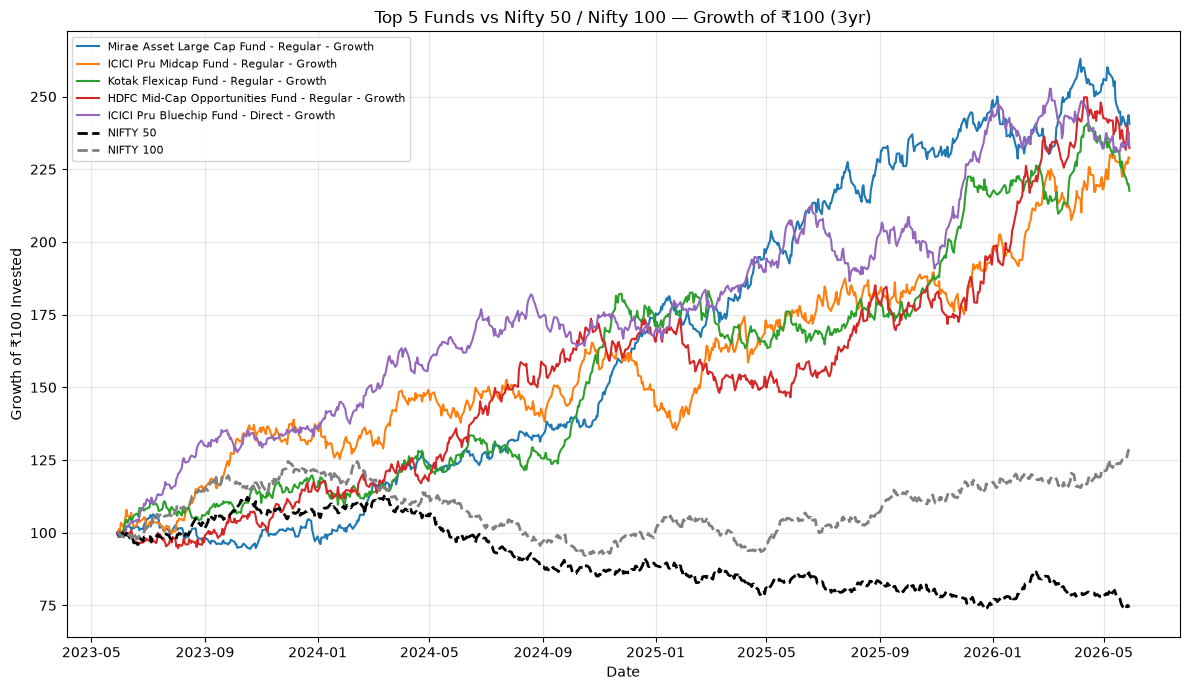

In [88]:
plt.figure(figsize=(12, 7))

for code in top5_codes:
    fund_data = nav_3yr[nav_3yr['amfi_code'] == code]
    fund_name = fund_master[fund_master['amfi_code'] == code]['scheme_name'].values[0]
    plt.plot(fund_data['date'], fund_data['growth_index'], label=fund_name)

plt.plot(nifty50_3yr['date'], nifty50_3yr['growth_index'], label='NIFTY 50', color='black', linestyle='--', linewidth=2)
plt.plot(nifty100_3yr['date'], nifty100_3yr['growth_index'], label='NIFTY 100', color='gray', linestyle='--', linewidth=2)

plt.title('Top 5 Funds vs Nifty 50 / Nifty 100 — Growth of ₹100 (3yr)')
plt.xlabel('Date')
plt.ylabel('Growth of ₹100 Invested')
plt.legend(loc='upper left', fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig('../reports/charts/benchmark_comparison_top5.png', dpi=150)
plt.show()

In [89]:
import os
print("Current working directory:", os.getcwd())
print()
print("Contents of parent folder:", os.listdir('..'))


Current working directory: C:\Users\aksha\OneDrive\Desktop\BLUE STOCK INTERNSHIP\Mutual-Fund-Analysis\notebooks

Contents of parent folder: ['.git', '.gitignore', '.venv', 'bluestock_mf.db', 'dashboard', 'data', 'data_dictionary.md', 'notebooks', 'reports', 'requirements.txt', 'sql']


In [90]:
print(os.listdir('../reports'))


['data_quality_summary.md']


In [91]:
os.makedirs('../reports/charts', exist_ok=True)
print(os.listdir('../reports'))

['charts', 'data_quality_summary.md']


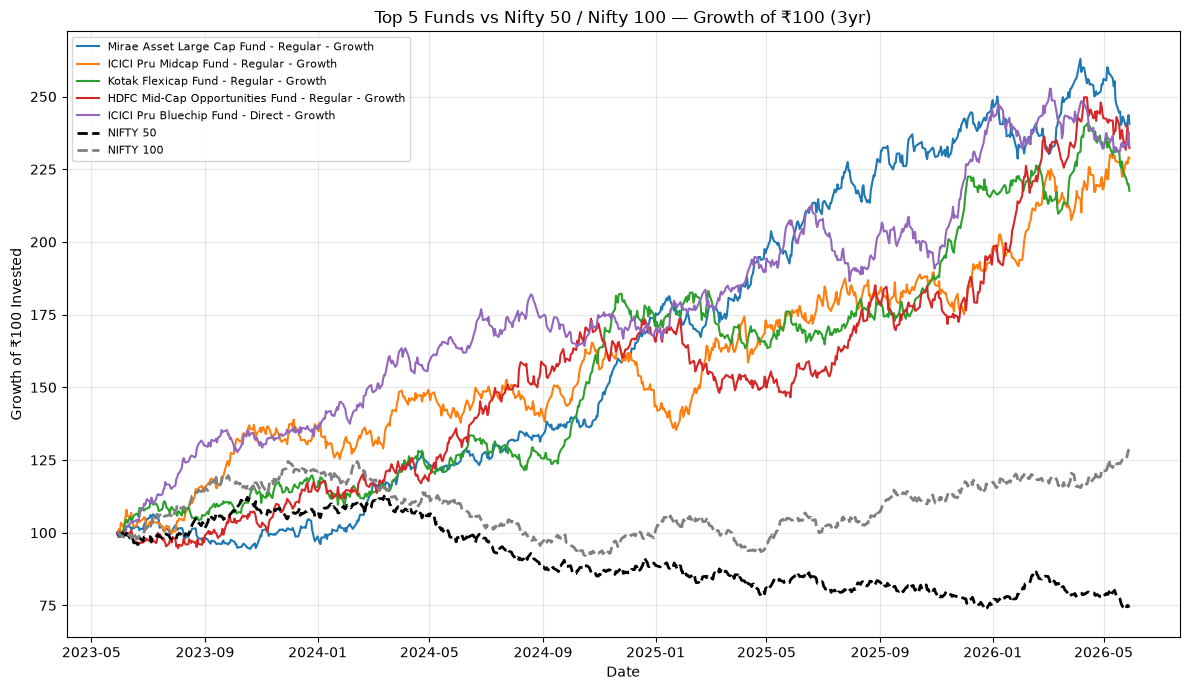

In [92]:
plt.figure(figsize=(12, 7))

for code in top5_codes:
    fund_data = nav_3yr[nav_3yr['amfi_code'] == code]
    fund_name = fund_master[fund_master['amfi_code'] == code]['scheme_name'].values[0]
    plt.plot(fund_data['date'], fund_data['growth_index'], label=fund_name)

plt.plot(nifty50_3yr['date'], nifty50_3yr['growth_index'], label='NIFTY 50', color='black', linestyle='--', linewidth=2)
plt.plot(nifty100_3yr['date'], nifty100_3yr['growth_index'], label='NIFTY 100', color='gray', linestyle='--', linewidth=2)

plt.title('Top 5 Funds vs Nifty 50 / Nifty 100 — Growth of ₹100 (3yr)')
plt.xlabel('Date')
plt.ylabel('Growth of ₹100 Invested')
plt.legend(loc='upper left', fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig('../reports/charts/benchmark_comparison_top5.png', dpi=150)
plt.show()